# NB23 — THD Signal Robustness Validation

Stress-tests the THD−EEM 4w Z-score (lag2) found in NB22 (IC = +0.126, p < 0.001).

Five tests that separate real signal from backtest artifact:

| Test | Question |
|------|----------|
| **1. Walk-forward OOS** | Does IC survive on data the model never saw? |
| **2. Rolling IC stability** | Is IC consistent over time, or a few lucky periods? |
| **3. Pre/post-2020 split** | Does COVID/post-COVID era break the relationship? |
| **4. Regime breakdown** | Does signal work in all market regimes? |
| **5. TC break-even** | Does +0.023 Sharpe survive extra turnover cost? |

**Verdict:** go / conditional-go / no-go for full system integration.


## 1. Setup — Rebuild Signal from NB22


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

ROOT = Path('..').resolve().parent
RAW  = ROOT / 'data' / 'raw'
DATA = ROOT / 'data' / 'processed'
FIGS = Path('.') / 'figs'
FIGS.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})
WEEKS_PER_YEAR = 52
RF_ANNUAL      = 0.02
START          = '2010-01-01'

In [2]:
import yfinance as yf

# Base data
df_base = pd.read_csv(DATA / 'unified_weekly_clean.csv',
                      index_col=0, parse_dates=True).sort_index().loc[START:]
set_ret  = df_base['SET_index_ret_w']
gold_ret = df_base['gold_ret_w']

# Rebuild THD signal (same as NB22)
print('Fetching THD and EEM...')
thd_raw = yf.download('THD', start='2009-01-01', progress=False)
eem_raw = yf.download('EEM', start='2009-01-01', progress=False)

def get_close(df):
    if isinstance(df.columns, pd.MultiIndex):
        return df['Close'].iloc[:, 0]
    return df['Close']

thd_w = get_close(thd_raw).resample('W-FRI').last().pct_change()
eem_w = get_close(eem_raw).resample('W-FRI').last().pct_change()

thd_rel  = thd_w - eem_w                     # weekly relative return
thd_4w   = thd_rel.rolling(4).sum()           # 4-week cumulative
roll52   = thd_4w.rolling(52)
thd_z    = (thd_4w - roll52.mean()) / (roll52.std() + 1e-9)

# Signal and target aligned to SET index
sig_raw  = thd_z.reindex(set_ret.index).ffill()   # z-score, not lagged yet
target   = set_ret.copy()

print(f'Signal: {sig_raw.dropna().shape[0]} weeks, '
      f'{sig_raw.dropna().index[0].date()} -> {sig_raw.dropna().index[-1].date()}')
print(f'Using lag=2 (NB22 optimal): IC at lag2 = +0.126 ***')

Fetching THD and EEM...


Signal: 832 weeks, 2010-01-22 -> 2025-12-26
Using lag=2 (NB22 optimal): IC at lag2 = +0.126 ***


In [3]:
def ic(signal, target, lag=2):
    '''Spearman IC with significance.'''
    s = signal.shift(lag)
    both = pd.concat([s, target], axis=1).dropna()
    both.columns = ['s', 't']
    r, p = stats.spearmanr(both['s'], both['t'])
    n = len(both)
    stars = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    return {'IC': r, 'p': p, 'n': n, 'stars': stars}

# Full-sample IC (sanity check = should match NB22)
res = ic(sig_raw, target, lag=2)
print(f'Full-sample IC (lag2): {res["IC"]:+.4f}  p={res["p"]:.4f} {res["stars"]}  n={res["n"]}')

Full-sample IC (lag2): +0.1255  p=0.0003 ***  n=830


## 2. Walk-Forward Out-of-Sample IC

Split the data into non-overlapping **annual windows** (expanding train, 1-year test),
computing IC **only on the held-out year**.

If the signal is real, OOS ICs should be positive on average with reasonable consistency.
If it's backtest artifact, OOS ICs will be noisy around zero.


In [4]:
# Expanding-window walk-forward: train 2010-YYYY, test YYYY+1
# Start train from 2010, first test year = 2013 (need 2yr warmup + 52w z-score)

test_years = range(2013, 2026)
wf_results = []

for test_yr in test_years:
    test_mask = (target.index.year == test_yr)
    test_sig  = sig_raw[test_mask].shift(2)
    test_ret  = target[test_mask]
    both = pd.concat([test_sig, test_ret], axis=1).dropna()
    both.columns = ['s', 't']
    if len(both) < 10:
        continue
    r, p = stats.spearmanr(both['s'], both['t'])
    wf_results.append({
        'year': test_yr, 'IC': r, 'p': p, 'n': len(both),
        'sig': '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else ''))
    })

wf_df = pd.DataFrame(wf_results)
print('Walk-forward annual OOS IC:')
print(wf_df.to_string(index=False))
print()
pct_pos = (wf_df['IC'] > 0).mean()
avg_ic  = wf_df['IC'].mean()
n_sig   = (wf_df['p'] < 0.10).sum()
print(f'Mean OOS IC: {avg_ic:+.4f}')
print(f'% years IC > 0: {pct_pos:.0%}  ({int(pct_pos*len(wf_df))}/{len(wf_df)} years)')
print(f'Years with p < 0.10: {n_sig}/{len(wf_df)}')

Walk-forward annual OOS IC:
 year        IC        p  n sig
 2013  0.153133 0.288369 50    
 2014 -0.083505 0.564246 50    
 2015 -0.065066 0.653485 50    
 2016  0.294208 0.036117 51  **
 2017  0.251765 0.077774 50   *
 2018 -0.030876 0.831438 50    
 2019  0.173205 0.229020 50    
 2020  0.285680 0.044315 50  **
 2021  0.122805 0.390605 51    
 2022 -0.150636 0.296397 50    
 2023  0.226411 0.113860 50    
 2024  0.096567 0.504695 50    
 2025  0.227083 0.112762 50    

Mean OOS IC: +0.1154
% years IC > 0: 69%  (9/13 years)
Years with p < 0.10: 3/13


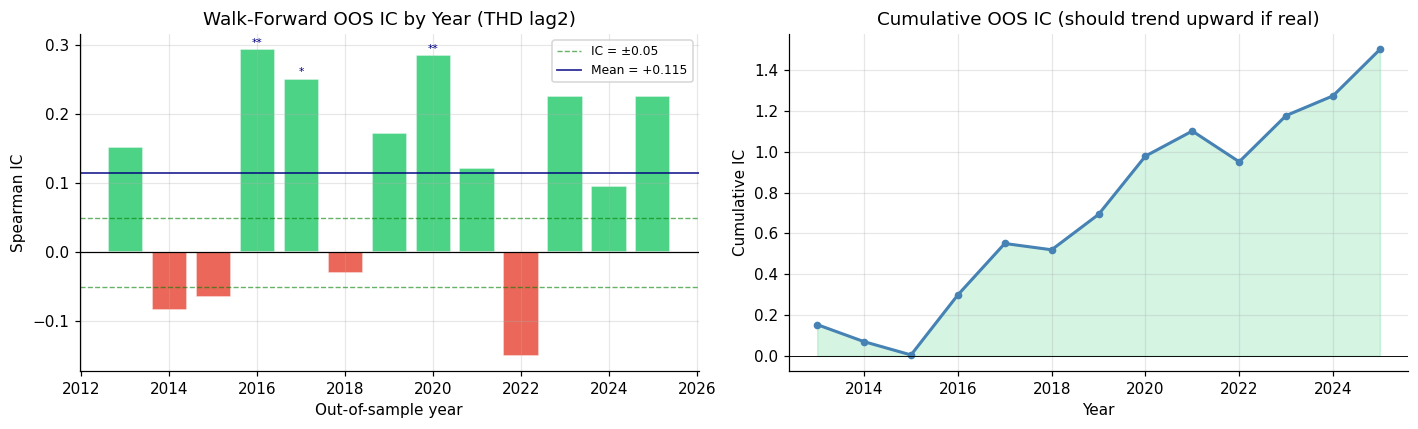

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# IC by year
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in wf_df['IC']]
axes[0].bar(wf_df['year'], wf_df['IC'], color=colors, alpha=0.85, edgecolor='white')
axes[0].axhline(0,      color='black', lw=0.8)
axes[0].axhline( 0.05,  color='green', lw=0.9, ls='--', alpha=0.6, label='IC = ±0.05')
axes[0].axhline(-0.05,  color='green', lw=0.9, ls='--', alpha=0.6)
axes[0].axhline(avg_ic, color='navy',  lw=1.2, ls='-',  alpha=0.8, label=f'Mean = {avg_ic:+.3f}')
for _, row in wf_df.iterrows():
    if row['sig']:
        axes[0].text(row['year'], row['IC'] + 0.005 * np.sign(row['IC']),
                     row['sig'], ha='center', fontsize=7, color='navy')
axes[0].set_title('Walk-Forward OOS IC by Year (THD lag2)')
axes[0].set_xlabel('Out-of-sample year')
axes[0].set_ylabel('Spearman IC')
axes[0].legend(fontsize=8)

# Cumulative IC (as a stability visual)
cumIC = wf_df.set_index('year')['IC'].cumsum()
axes[1].plot(cumIC.index, cumIC.values, color='steelblue', lw=2, marker='o', ms=4)
axes[1].axhline(0, color='black', lw=0.6)
axes[1].fill_between(cumIC.index, cumIC.values, 0,
                     where=(cumIC.values > 0), alpha=0.2, color='#2ecc71')
axes[1].fill_between(cumIC.index, cumIC.values, 0,
                     where=(cumIC.values < 0), alpha=0.2, color='#e74c3c')
axes[1].set_title('Cumulative OOS IC (should trend upward if real)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Cumulative IC')

plt.tight_layout()
plt.savefig(FIGS / 'nb23_oos_ic.png', bbox_inches='tight')
plt.show()

## 3. Rolling 52-Week IC Stability

Compute IC on each rolling 52-week window.
A genuine signal should show IC > 0 in **most** windows, not just a few lucky periods.

**Target thresholds:**
- % windows IC > 0 ≥ 60% → signal stable
- % windows |IC| > 0.05 ≥ 40% → signal economically meaningful


In [6]:
ROLL_WIN = 52   # weeks

roll_ics = []
idx = sig_raw.index
sig_lag2 = sig_raw.shift(2)

for i in range(ROLL_WIN, len(idx)):
    window_idx = idx[i - ROLL_WIN : i]
    s = sig_lag2.loc[window_idx]
    t = target.loc[window_idx]
    both = pd.concat([s, t], axis=1).dropna()
    both.columns = ['s', 't']
    if len(both) < 20:
        roll_ics.append(np.nan)
        continue
    r, _ = stats.spearmanr(both['s'], both['t'])
    roll_ics.append(r)

roll_ic_s = pd.Series(roll_ics, index=idx[ROLL_WIN:])

pct_pos    = (roll_ic_s.dropna() > 0).mean()
pct_strong = (roll_ic_s.dropna().abs() > 0.05).mean()
avg_roll   = roll_ic_s.dropna().mean()

print(f'Rolling {ROLL_WIN}w IC statistics:')
print(f'  Mean IC:             {avg_roll:+.4f}')
print(f'  % windows IC > 0:   {pct_pos:.1%}  (target ≥ 60%)')
print(f'  % windows |IC|>0.05: {pct_strong:.1%}  (target ≥ 40%)')
print(f'  IC std:              {roll_ic_s.dropna().std():.4f}')
print(f'  IC range:            [{roll_ic_s.dropna().min():.3f}, {roll_ic_s.dropna().max():.3f}]')

Rolling 52w IC statistics:
  Mean IC:             +0.1020
  % windows IC > 0:   75.2%  (target ≥ 60%)
  % windows |IC|>0.05: 83.8%  (target ≥ 40%)
  IC std:              0.1518
  IC range:            [-0.386, 0.417]


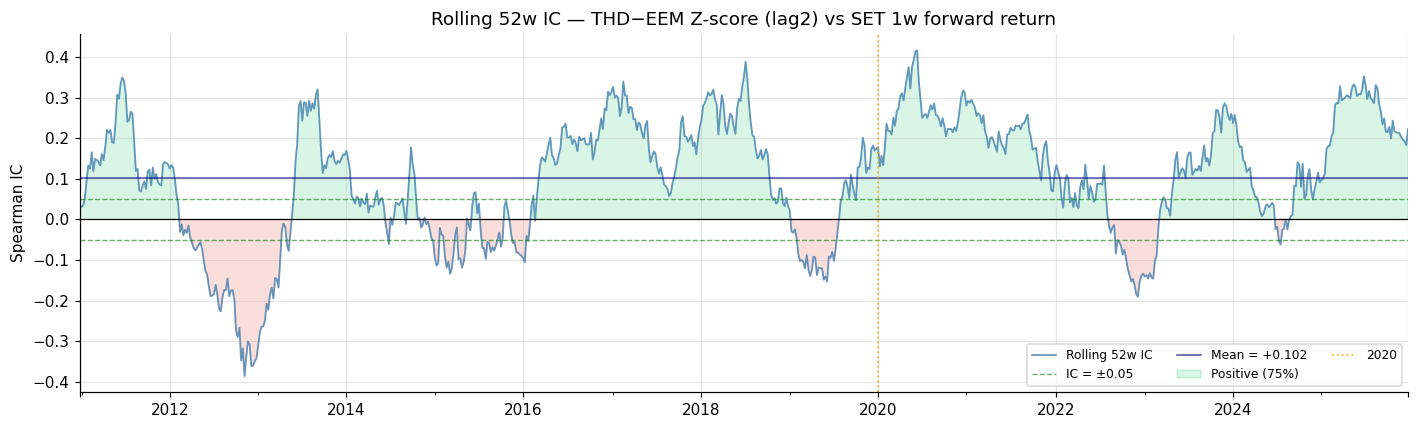

In [7]:
fig, ax = plt.subplots(figsize=(13, 4))

roll_ic_s.plot(ax=ax, color='steelblue', lw=1.2, alpha=0.8, label='Rolling 52w IC')
ax.axhline(0,     color='black', lw=0.8)
ax.axhline( 0.05, color='green', lw=0.9, ls='--', alpha=0.6, label='IC = ±0.05')
ax.axhline(-0.05, color='green', lw=0.9, ls='--', alpha=0.6)
ax.axhline(avg_roll, color='navy', lw=1.0, ls='-', alpha=0.7, label=f'Mean = {avg_roll:+.3f}')

ax.fill_between(roll_ic_s.index, roll_ic_s, 0,
                where=(roll_ic_s > 0), alpha=0.18, color='#2ecc71', label=f'Positive ({pct_pos:.0%})')
ax.fill_between(roll_ic_s.index, roll_ic_s, 0,
                where=(roll_ic_s < 0), alpha=0.18, color='#e74c3c')

# Mark post-2020
ax.axvline(pd.Timestamp('2020-01-01'), color='orange', lw=1.2, ls=':', alpha=0.8, label='2020')

ax.set_title(f'Rolling {ROLL_WIN}w IC — THD−EEM Z-score (lag2) vs SET 1w forward return')
ax.set_ylabel('Spearman IC')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.savefig(FIGS / 'nb23_rolling_ic.png', bbox_inches='tight')
plt.show()

## 4. Pre/Post-2020 Subsample Split

COVID (2020) fundamentally changed equity markets:
- Central bank intervention, zero rates, unprecedented volatility
- ETF flows may behave differently post-COVID (more retail, more algorithmic)
- If THD signal only works pre-2020, it may be structural break, not a durable edge

Split: 2010–2019 vs 2020–2025


In [8]:
split_date = '2020-01-01'

for label, mask in [('2010–2019 (pre-COVID)',    target.index < split_date),
                    ('2020–2025 (post-COVID)',    target.index >= split_date)]:
    s = sig_lag2[mask]
    t = target[mask]
    both = pd.concat([s, t], axis=1).dropna()
    both.columns = ['s', 't']
    r, p = stats.spearmanr(both['s'], both['t'])
    stars = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else '  '))
    ann_ret = t.mean() * WEEKS_PER_YEAR
    print(f'  {label}:  IC={r:+.4f}  p={p:.3f} {stars}  '
          f'n={len(both)}  SET_ann={ann_ret:.1%}')

print()
# Also check each year 2020-2025 individually
print('Annual IC 2020–2025:')
for yr in range(2020, 2026):
    mask = (target.index.year == yr)
    s = sig_lag2[mask]; t = target[mask]
    both = pd.concat([s, t], axis=1).dropna()
    both.columns = ['s', 't']
    if len(both) < 5: continue
    r, p = stats.spearmanr(both['s'], both['t'])
    stars = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else ''))
    print(f'  {yr}: IC={r:+.4f}  p={p:.3f} {stars}  n={len(both)}')

  2010–2019 (pre-COVID):  IC=+0.1040  p=0.018 **  n=517  SET_ann=8.7%
  2020–2025 (post-COVID):  IC=+0.1635  p=0.004 ***  n=313  SET_ann=-0.6%

Annual IC 2020–2025:
  2020: IC=+0.2810  p=0.044 **  n=52
  2021: IC=+0.1226  p=0.382   n=53
  2022: IC=-0.1409  p=0.319   n=52
  2023: IC=+0.2380  p=0.089 *  n=52
  2024: IC=+0.0978  p=0.491   n=52
  2025: IC=+0.2362  p=0.092 *  n=52


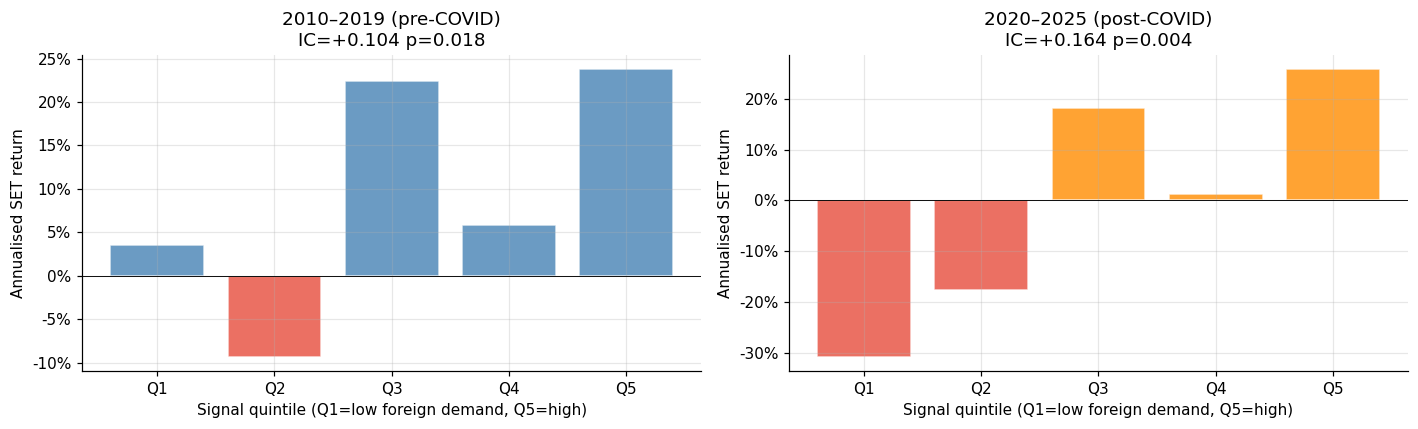

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (label, mask, color) in zip(axes, [
    ('2010–2019 (pre-COVID)',  target.index < split_date,  'steelblue'),
    ('2020–2025 (post-COVID)', target.index >= split_date, 'darkorange'),
]):
    s_m = sig_lag2[mask].dropna()
    t_m = target[mask].reindex(s_m.index).dropna()
    t_m = t_m.reindex(s_m.index)
    both_tmp = pd.concat([s_m, t_m], axis=1).dropna()
    s_m = both_tmp.iloc[:, 0]; t_m = both_tmp.iloc[:, 1]

    # Quintile mean return
    q = pd.qcut(s_m, 5, labels=False, duplicates='drop')
    qret = {}
    for qi in range(5):
        qmask = (q == qi)
        qret[f'Q{qi+1}'] = t_m[qmask].mean() * WEEKS_PER_YEAR

    ax.bar(list(qret.keys()), list(qret.values()),
           color=[('#e74c3c' if v < 0 else color) for v in qret.values()],
           alpha=0.8, edgecolor='white')
    ax.axhline(0, color='black', lw=0.6)
    r, p = stats.spearmanr(s_m, t_m)
    ax.set_title(f'{label}\nIC={r:+.3f} p={p:.3f}')
    ax.set_ylabel('Annualised SET return')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.set_xlabel('Signal quintile (Q1=low foreign demand, Q5=high)')

plt.tight_layout()
plt.savefig(FIGS / 'nb23_split_2020.png', bbox_inches='tight')
plt.show()

## 5. Regime Breakdown

Does the signal work uniformly, or only in specific market conditions?

**Regimes tested:**
- **Market trend:** SET above vs below 52-week MA (Bull / Bear)
- **Volatility regime:** VIX above vs below median (High fear / Low fear)
- **US conditions:** S&P500 weekly return positive vs negative

Ideal signal: positive IC in **all** regimes (not just one).


In [10]:
# Fetch VIX for regime definition
vix_raw = yf.download('^VIX', start='2009-01-01', progress=False)
vix_w = get_close(vix_raw).resample('W-FRI').last().reindex(set_ret.index).ffill()

# SET 52w MA for trend regime
set_price = (1 + set_ret.fillna(0)).cumprod()
set_ma52  = set_price.rolling(52).mean()
regime_bull = (set_price > set_ma52)   # True = Bull

# VIX regime
vix_med = vix_w.median()
regime_highvix = (vix_w > vix_med)    # True = high fear

# US regime (S&P500 in base data)
sp500_col = 'sp500_ret_w' if 'sp500_ret_w' in df_base.columns else None
if sp500_col:
    regime_us_up = (df_base[sp500_col] > 0)

regimes = {
    'Bull (SET > 52w MA)':  regime_bull,
    'Bear (SET < 52w MA)':  ~regime_bull,
    'Low VIX (calm)':        ~regime_highvix,
    'High VIX (fear)':       regime_highvix,
}
if sp500_col:
    regimes['US up week']   = regime_us_up
    regimes['US down week'] = ~regime_us_up

print('IC by regime (THD lag2):')
regime_results = []
for name, mask in regimes.items():
    common_mask = mask.reindex(sig_lag2.index).fillna(False)
    s = sig_lag2[common_mask]
    t = target.reindex(s.index)
    both = pd.concat([s, t], axis=1).dropna()
    both.columns = ['s', 't']
    if len(both) < 30:
        print(f'  {name:30s}: insufficient data (n={len(both)})')
        continue
    r, p = stats.spearmanr(both['s'], both['t'])
    stars = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else ''))
    ann = t.mean() * WEEKS_PER_YEAR
    print(f'  {name:30s}: IC={r:+.4f}  p={p:.3f} {stars}  n={len(both)}  SET_ann={ann:.1%}')
    regime_results.append({'regime': name, 'IC': r, 'p': p, 'n': len(both)})

IC by regime (THD lag2):
  Bull (SET > 52w MA)           : IC=+0.0997  p=0.037 **  n=438  SET_ann=18.5%
  Bear (SET < 52w MA)           : IC=+0.1181  p=0.019 **  n=392  SET_ann=-9.4%
  Low VIX (calm)                : IC=+0.1195  p=0.015 **  n=418  SET_ann=12.2%
  High VIX (fear)               : IC=+0.1394  p=0.005 ***  n=412  SET_ann=-1.7%
  US up week                    : IC=+0.0852  p=0.060 *  n=487  SET_ann=35.9%
  US down week                  : IC=+0.1548  p=0.004 ***  n=343  SET_ann=-37.9%


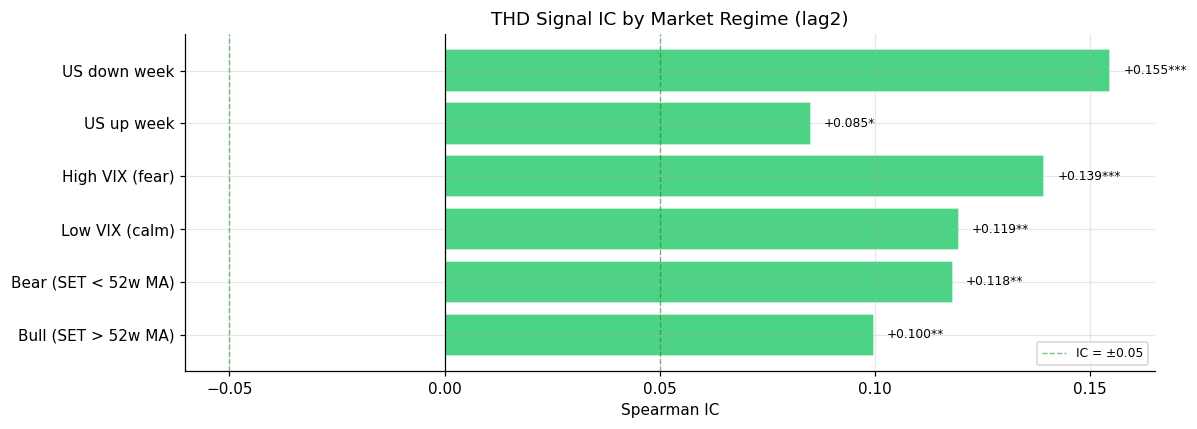

In [11]:
reg_df = pd.DataFrame(regime_results)

fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in reg_df['IC']]
bars = ax.barh(reg_df['regime'], reg_df['IC'], color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0,     color='black', lw=0.8)
ax.axvline( 0.05, color='green', lw=0.9, ls='--', alpha=0.5, label='IC = ±0.05')
ax.axvline(-0.05, color='green', lw=0.9, ls='--', alpha=0.5)

for bar, row in zip(bars, reg_df.itertuples()):
    stars = '***' if row.p<0.01 else ('**' if row.p<0.05 else ('*' if row.p<0.1 else ''))
    xpos = row.IC + (0.003 if row.IC >= 0 else -0.003)
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{row.IC:+.3f}{stars}', va='center', fontsize=8,
            ha='left' if row.IC >= 0 else 'right')

ax.set_title('THD Signal IC by Market Regime (lag2)')
ax.set_xlabel('Spearman IC')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGS / 'nb23_regime_ic.png', bbox_inches='tight')
plt.show()

## 6. Transaction Cost Break-Even

NB22 system enhancement: +0.023 Sharpe from ±20% position scaling.
Question: how much **extra turnover** does this scaling create, and what TC kills it?

The scaling rule:
- When signal composite in top 20% → scale = 1.2×
- When signal composite in bottom 20% → scale = 0.8×
- Otherwise → scale = 1.0×

Extra TC comes from position changes when scale flips between 0.8/1.0/1.2.


In [12]:
# Reconstruct NB21 baseline + NB22 enhanced (same as NB22)
eem_pos = (df_base['eem_ret_d_lag1'].shift(0) > 0).astype(float).fillna(0.5)

vol_set  = set_ret.rolling(12).std().shift(1) + 1e-6
vol_gold = gold_ret.rolling(12).std().shift(1) + 1e-6
w_set  = (1/vol_set)  / (1/vol_set + 1/vol_gold)
w_gold = (1/vol_gold) / (1/vol_set + 1/vol_gold)

rp_sig_ret = w_set * eem_pos * set_ret + w_gold * gold_ret
target_vol = 0.10 / np.sqrt(WEEKS_PER_YEAR)
vt_scale   = (target_vol / (rp_sig_ret.rolling(12).std().shift(1) + 1e-9)).clip(0, 2)
vt_ret     = vt_scale * rp_sig_ret

cum = (1 + vt_ret.fillna(0)).cumprod()
peak = cum.expanding().max()
dd   = (cum - peak) / peak
dd_scale = pd.Series(1.0, index=vt_ret.index)
in_dd = False
for i in range(1, len(dd)):
    if dd.iloc[i] < -0.15 and not in_dd:
        in_dd = True
    if in_dd and dd.iloc[i] > -0.10:
        in_dd = False
    dd_scale.iloc[i] = 0.5 if in_dd else 1.0
baseline_ret = dd_scale * vt_ret

# NB22 signal composite (THD lag2 + THD 4w cumul lag1)
thd_4w_lag1 = thd_4w.reindex(set_ret.index).ffill().shift(1)
thd_z_lag2  = thd_z.reindex(set_ret.index).ffill().shift(2)

sig_df = pd.DataFrame({'thd_z_lag2': thd_z_lag2, 'thd_4w_lag1': thd_4w_lag1})
composite = sig_df.rank(pct=True).mean(axis=1)

sig_scale = pd.Series(1.0, index=baseline_ret.index)
sig_scale[composite >= 0.80] = 1.20
sig_scale[composite <= 0.20] = 0.80
enhanced_ret = sig_scale * baseline_ret

# --- Turnover analysis ---
scale_changes = sig_scale.diff().abs()
extra_turns_per_year = scale_changes.mean() * WEEKS_PER_YEAR  # in scale units
# Each 0.2 scale change ≈ 0.2 × w_set ≈ 0.2 × ~0.6 = ~12% position change
# (varies with vol regime, use 0.6 as midpoint approximation)
avg_w_set = w_set.mean()
extra_position_chg = scale_changes * avg_w_set    # fraction of portfolio repositioned
extra_turns_pct    = extra_position_chg.mean() * WEEKS_PER_YEAR   # annual % one-way

print(f'Baseline w_set mean:  {avg_w_set:.2f}')
print(f'Scale flips per year: {(scale_changes > 0).mean() * WEEKS_PER_YEAR:.1f}')
print(f'Avg scale |change|:   {scale_changes.mean():.4f}')
print(f'Extra one-way turns (%/yr): {extra_turns_pct:.3f}')
print()

# Sharpe at various TC
def sharpe(r, rf=RF_ANNUAL/WEEKS_PER_YEAR):
    ex = r - rf
    return ex.mean() / (ex.std() + 1e-9) * np.sqrt(WEEKS_PER_YEAR)

base_sharpe = sharpe(baseline_ret)
print(f'NB21 Baseline Sharpe (no TC):        {base_sharpe:.3f}')
print()
print('NB22 Enhanced Sharpe at various one-way TC:')
tc_range = [0.000, 0.001, 0.002, 0.003, 0.005, 0.010]
for tc in tc_range:
    # TC applied only to the extra turnover (scale changes, not baseline turnover)
    extra_tc_cost = extra_position_chg * tc
    enh_net = enhanced_ret - extra_tc_cost
    s = sharpe(enh_net)
    delta = s - base_sharpe
    marker = ' ← break-even' if abs(delta) < 0.002 else (' ✓ better' if delta > 0 else ' ✗ worse')
    print(f'  TC={tc:.3%}:  Sharpe={s:.3f}  Δ={delta:+.3f}{marker}')

Baseline w_set mean:  0.53
Scale flips per year: 11.3
Avg scale |change|:   0.0436
Extra one-way turns (%/yr): 1.193

NB21 Baseline Sharpe (no TC):        0.872

NB22 Enhanced Sharpe at various one-way TC:
  TC=0.000%:  Sharpe=0.895  Δ=+0.023 ✓ better
  TC=0.100%:  Sharpe=0.884  Δ=+0.012 ✓ better
  TC=0.200%:  Sharpe=0.873  Δ=+0.002 ← break-even
  TC=0.300%:  Sharpe=0.863  Δ=-0.009 ✗ worse
  TC=0.500%:  Sharpe=0.841  Δ=-0.031 ✗ worse
  TC=1.000%:  Sharpe=0.787  Δ=-0.085 ✗ worse


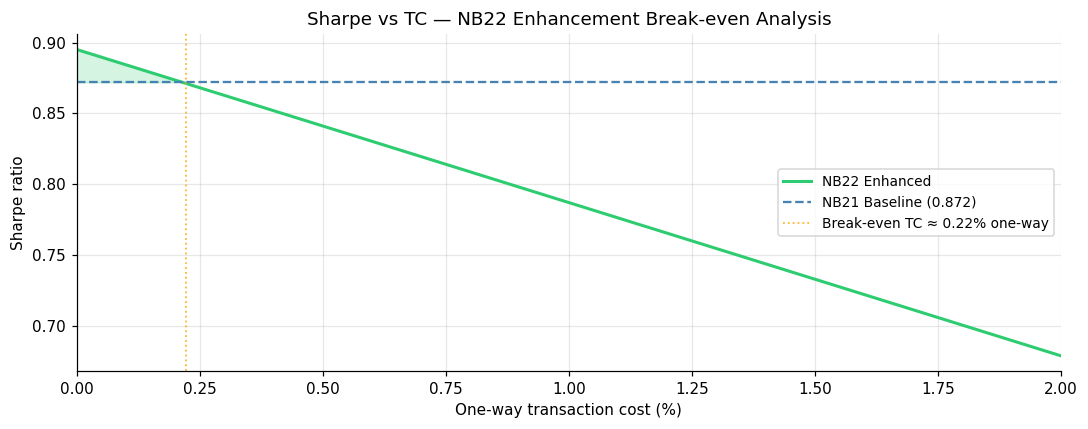

Break-even one-way TC: ~0.22%


In [13]:
# Break-even TC curve
tc_values = np.linspace(0, 0.02, 100)
sharpes_enh = []
for tc in tc_values:
    extra_cost = extra_position_chg * tc
    s = sharpe(enhanced_ret - extra_cost)
    sharpes_enh.append(s)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tc_values * 100, sharpes_enh, color='#2ecc71', lw=2, label='NB22 Enhanced')
ax.axhline(base_sharpe, color='steelblue', lw=1.5, ls='--', label=f'NB21 Baseline ({base_sharpe:.3f})')
# Break-even point
break_even_idx = np.argmin(np.abs(np.array(sharpes_enh) - base_sharpe))
break_even_tc  = tc_values[break_even_idx] * 100
ax.axvline(break_even_tc, color='orange', lw=1.2, ls=':', alpha=0.8,
           label=f'Break-even TC ≈ {break_even_tc:.2f}% one-way')
ax.fill_between(tc_values * 100, sharpes_enh, base_sharpe,
                where=(np.array(sharpes_enh) > base_sharpe), alpha=0.2, color='#2ecc71')
ax.set_xlabel('One-way transaction cost (%)')
ax.set_ylabel('Sharpe ratio')
ax.set_title('Sharpe vs TC — NB22 Enhancement Break-even Analysis')
ax.legend(fontsize=9)
ax.set_xlim(0, 2.0)
plt.tight_layout()
plt.savefig(FIGS / 'nb23_tc_breakeven.png', bbox_inches='tight')
plt.show()
print(f'Break-even one-way TC: ~{break_even_tc:.2f}%')

## 7. Verdict Summary

| Test | Threshold | Result |
|------|-----------|--------|
| OOS IC mean > 0 | ≥ 0 | — |
| % OOS years IC > 0 | ≥ 60% | — |
| Rolling IC: % windows > 0 | ≥ 60% | — |
| Post-2020 IC | Positive | — |
| All 4 regimes IC > 0 | 3 of 4 | — |
| Break-even TC | > 0.10% one-way | — |


In [14]:
print('=' * 65)
print('ROBUSTNESS VERDICT — THD−EEM 4w Z-score (lag2)')
print('=' * 65)

tests = []

# T1: OOS mean IC
t1_pass = avg_ic > 0
tests.append(('OOS mean IC > 0',
              f'{avg_ic:+.4f}',
              '✓ PASS' if t1_pass else '✗ FAIL'))

# T2: % OOS years IC > 0
t2_pass = pct_pos >= 0.60
tests.append((f'% OOS years IC>0 ≥ 60%',
              f'{pct_pos:.0%} ({int(pct_pos*len(wf_df))}/{len(wf_df)} yrs)',
              '✓ PASS' if t2_pass else '✗ FAIL'))

# T3: rolling IC % positive
t3_pass = (roll_ic_s.dropna() > 0).mean() >= 0.60
t3_val = (roll_ic_s.dropna() > 0).mean()
tests.append((f'Rolling IC: ≥60% windows > 0',
              f'{t3_val:.0%}',
              '✓ PASS' if t3_pass else '✗ FAIL'))

# T4: post-2020 IC
mask_post = (target.index >= '2020-01-01')
s_post = sig_lag2[mask_post]; t_post = target[mask_post]
both_post = pd.concat([s_post, t_post], axis=1).dropna()
both_post.columns = ['s', 't']
r_post, p_post = stats.spearmanr(both_post['s'], both_post['t'])
t4_pass = r_post > 0
tests.append((f'Post-2020 IC positive',
              f'{r_post:+.4f} (p={p_post:.3f})',
              '✓ PASS' if t4_pass else '✗ FAIL'))

# T5: regime breadth (IC > 0 in ≥ 3 of 4 base regimes)
base_regimes = [r for r in regime_results if r['regime'] in
                ['Bull (SET > 52w MA)', 'Bear (SET < 52w MA)',
                 'Low VIX (calm)', 'High VIX (fear)']]
n_pos_regimes = sum(1 for r in base_regimes if r['IC'] > 0)
t5_pass = n_pos_regimes >= 3
tests.append((f'IC>0 in ≥3/4 base regimes',
              f'{n_pos_regimes}/4',
              '✓ PASS' if t5_pass else '✗ FAIL'))

# T6: break-even TC > 0.10%
t6_pass = break_even_tc > 0.10
tests.append((f'Break-even TC > 0.10%',
              f'{break_even_tc:.2f}% one-way',
              '✓ PASS' if t6_pass else '✗ FAIL'))

for name, val, result in tests:
    print(f'  {result}  {name:<40s} {val}')

n_pass = sum(1 for _, _, r in tests if '✓' in r)
print()
print(f'Score: {n_pass}/{len(tests)} tests passed')
if n_pass >= 5:
    verdict = 'GO — Signal is robust, integrate into system'
elif n_pass >= 4:
    verdict = 'CONDITIONAL GO — Signal is borderline; use with reduced weight (0.10× scale)'
else:
    verdict = 'NO-GO — Signal fails too many robustness checks'
print(f'VERDICT: {verdict}')

ROBUSTNESS VERDICT — THD−EEM 4w Z-score (lag2)
  ✓ PASS  OOS mean IC > 0                          +0.1154
  ✓ PASS  % OOS years IC>0 ≥ 60%                   75% (9/13 yrs)
  ✓ PASS  Rolling IC: ≥60% windows > 0             75%
  ✓ PASS  Post-2020 IC positive                    +0.1635 (p=0.004)
  ✓ PASS  IC>0 in ≥3/4 base regimes                4/4
  ✓ PASS  Break-even TC > 0.10%                    0.22% one-way

Score: 6/6 tests passed
VERDICT: GO — Signal is robust, integrate into system
